# Model Comparison & Feature Selection Demo

This notebook demonstrates two critical ML concepts using the geospatial site scoring pipeline:

1. **Task Comparison** — Regression (predict revenue) vs Lookalike Classification (identify top performers)
2. **Feature Selection Experiments** — How different feature subsets reveal bias, overfitting, and data leakage

All experiments use sklearn's **HistGradientBoosting** models (histogram-based gradient boosting, similar to XGBoost/LightGBM) with **permutation importance** for feature analysis.

---
## Section 1: Setup & Data Loading

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, f1_score, precision_score, recall_score,
    log_loss, roc_curve, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Load training data
PROJECT_ROOT = Path('.').resolve()
train_pl = pl.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'site_training_data.parquet')
print(f'Loaded {train_pl.shape[0]:,} sites x {train_pl.shape[1]} columns')

Loaded 26,099 sites x 111 columns


In [2]:
# Define numeric, categorical, and boolean features
NUMERIC_FEATURES = [
    
    # Multi-horizon relative strength indicators
    'rs_NVIs_95_185', 'rs_Revenue_95_185',
    # 'rs_NVIs_185_370', 'rs_Revenue_185_370',
    # 'rs_NVIs_370_740', 'rs_Revenue_370_740',
    
    # Revenue metrics
    # 'log_total_revenue',
    # Geospatial distances
    'log_min_distance_to_nearest_site_mi', 'log_min_distance_to_interstate_mi',
    'log_min_distance_to_kroger_mi', 'log_min_distance_to_mcdonalds_mi',
    'log_min_distance_to_walmart_mi', 'log_min_distance_to_target_mi',
    # Demographics
    'log_avg_household_income', 'median_age', 'pct_female','pct_asian'
]

CATEGORICAL_FEATURES = [
    'network', 'program', 'experience_type', 'hardware_type',
    'retailer', 'brand_fuel', 'brand_c_store',
]

BOOLEAN_FEATURES = [
    'r_retail_car_wash_encoded', 'r_cpg_beverage_beer_oof_encoded',
    'r_cpg_beverage_beer_vide_encoded', 'r_cpg_beverage_wine_oof_encoded',
    'r_cpg_beverage_wine_video_encoded', 'r_finance_credit_cards_encoded',
    'r_cpg_cbd_hemp_ingestibles_non_thc_encoded',
    'r_cpg_non_food_beverage_cannabis_medical_encoded',
    'r_cpg_non_food_beverage_cannabis_recreational_encoded',
    'r_cpg_non_food_beverage_cbd_hemp_non_thc_encoded',
    'r_automotive_after_market_oil_encoded',
    'r_cpg_beverage_spirits_ooh_encoded', 'r_cpg_beverage_spirits_video_encoded',
    'r_cpg_non_food_beverage_e_cigarette_encoded',
    'r_entertainment_casinos_and_gambling_encoded',
    'r_government_political_encoded', 'r_automotive_electric_encoded',
    'r_recruitment_encoded', 'r_restaurants_cdr_encoded', 'r_restaurants_qsr_encoded',
    'r_retail_automotive_service_encoded', 'r_retail_grocery_encoded',
    'r_retail_grocerty_with_fuel_encoded',
    'c_emv_enabled_encoded', 'c_nfc_enabled_encoded', 'c_open_24_hours_encoded',
    'c_sells_beer_encoded', 'c_sells_diesel_fuel_encoded', 'c_sells_lottery_encoded',
    'c_vistar_programmatic_enabled_encoded', 'c_sells_wine_encoded',
    'schedule_site_encoded', 'sellable_site_encoded',
]

TARGET = 'avg_monthly_revenue'
LOOKALIKE_PERCENTILE = 90  # p90+ = top performers

# Filter to features that actually exist in the dataset
available_cols = set(train_pl.columns)
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in available_cols]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in available_cols]
BOOLEAN_FEATURES = [f for f in BOOLEAN_FEATURES if f in available_cols]

print(f'Numeric:     {len(NUMERIC_FEATURES)} features')
print(f'Categorical: {len(CATEGORICAL_FEATURES)} features')
print(f'Boolean:     {len(BOOLEAN_FEATURES)} features')
print(f'Total:       {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES) + len(BOOLEAN_FEATURES)} features')

Numeric:     12 features
Categorical: 7 features
Boolean:     33 features
Total:       52 features


In [3]:
# Prepare model-ready DataFrame
# Label-encode categoricals (HistGradientBoosting needs numeric input)
df = train_pl.to_pandas()

label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].fillna('__MISSING__').astype(str))
    label_encoders[col] = le

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BOOLEAN_FEATURES

# Fill NaN in numeric/boolean features
for col in NUMERIC_FEATURES + BOOLEAN_FEATURES:
    df[col] = df[col].fillna(0)

# Create regression target
y_reg = df[TARGET].values

# Create classification target (p90 threshold)
threshold = np.percentile(y_reg, LOOKALIKE_PERCENTILE)
y_cls = (y_reg >= threshold).astype(int)

# Feature matrix
X = df[ALL_FEATURES].values

# Row indices for mapping predictions back to site IDs (gtvid)
indices = np.arange(len(df))

# Train/test split (fixed seed for all experiments)
# Include indices so we can recover df rows for export
X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test, idx_train, idx_test = train_test_split(
    X, y_reg, y_cls, indices, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')
print(f'\nRegression target: median=${np.median(y_reg):,.0f}, mean=${y_reg.mean():,.0f}')
print(f'Classification threshold (p{LOOKALIKE_PERCENTILE}): ${threshold:,.0f}')
print(f'  Positive class: {y_cls.sum():,} sites ({y_cls.mean()*100:.1f}%)')

# Shared model parameters
hgb_params = dict(
    max_iter=500, learning_rate=0.03, max_depth=6,
    random_state=42, verbose=0,
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=50,
)
print(f'\nModel params: {hgb_params}')

Train: 20,879 samples
Test:  5,220 samples

Regression target: median=$176, mean=$268
Classification threshold (p90): $613
  Positive class: 2,610 sites (10.0%)

Model params: {'max_iter': 500, 'learning_rate': 0.03, 'max_depth': 6, 'random_state': 42, 'verbose': 0, 'early_stopping': True, 'validation_fraction': 0.15, 'n_iter_no_change': 50}


---
## Section 2: Task Comparison — Regression vs Classification

Same features, same data, two fundamentally different questions:
- **Regression**: "How much revenue will this site generate?"
- **Classification**: "Is this site in the top 10% of performers?"

In [4]:
# Train Regression Model
reg_model = HistGradientBoostingRegressor(loss='squared_error', **hgb_params)
reg_model.fit(X_train, y_reg_train)

y_reg_pred_train = reg_model.predict(X_train)
y_reg_pred_test = reg_model.predict(X_test)

reg_metrics = {
    'Train RMSE': np.sqrt(mean_squared_error(y_reg_train, y_reg_pred_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_test)),
    'Train R2': r2_score(y_reg_train, y_reg_pred_train),
    'Test R2': r2_score(y_reg_test, y_reg_pred_test),
    'Train MAE': mean_absolute_error(y_reg_train, y_reg_pred_train),
    'Test MAE': mean_absolute_error(y_reg_test, y_reg_pred_test),
}

print('=== Regression Results ===')
for k, v in reg_metrics.items():
    fmt = f'${v:,.0f}' if 'MAE' in k or 'RMSE' in k else f'{v:.4f}'
    print(f'  {k:15s} {fmt}')
print(f'  Iterations used: {reg_model.n_iter_}')

=== Regression Results ===
  Train RMSE      $171
  Test RMSE       $212
  Train R2        0.6277
  Test R2         0.4522
  Train MAE       $114
  Test MAE        $134
  Iterations used: 500


In [5]:
# Train Classification Model (Lookalike)
cls_model = HistGradientBoostingClassifier(loss='log_loss', **hgb_params)
cls_model.fit(X_train, y_cls_train)

y_cls_pred_test = cls_model.predict(X_test)
y_cls_prob_test = cls_model.predict_proba(X_test)[:, 1]
y_cls_prob_train = cls_model.predict_proba(X_train)[:, 1]

cls_metrics = {
    'Train AUC': roc_auc_score(y_cls_train, y_cls_prob_train),
    'Test AUC': roc_auc_score(y_cls_test, y_cls_prob_test),
    'Test F1': f1_score(y_cls_test, y_cls_pred_test),
    'Test Precision': precision_score(y_cls_test, y_cls_pred_test),
    'Test Recall': recall_score(y_cls_test, y_cls_pred_test),
    'Test Log Loss': log_loss(y_cls_test, y_cls_prob_test),
}

print('=== Classification Results ===')
for k, v in cls_metrics.items():
    print(f'  {k:17s} {v:.4f}')
print(f'  Iterations used: {cls_model.n_iter_}')

=== Classification Results ===
  Train AUC         0.9572
  Test AUC          0.8700
  Test F1           0.4730
  Test Precision    0.6793
  Test Recall       0.3628
  Test Log Loss     0.2289
  Iterations used: 348


Computing permutation importance (this takes ~30s)...


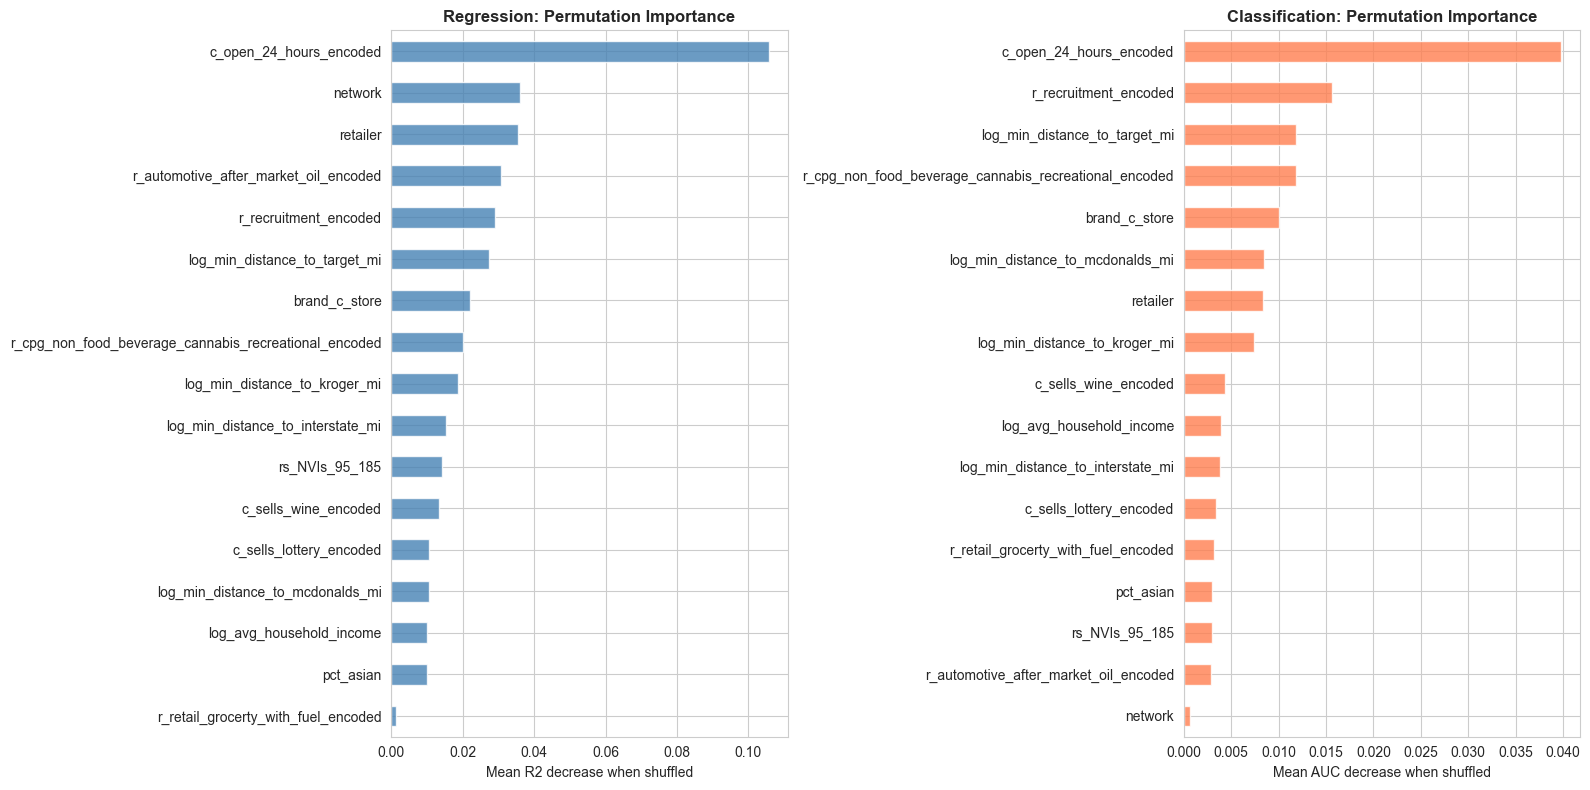


Rank correlation (Spearman) between regression and classification importance: rho = 0.722 (p = 1.55e-09)
-> High correlation means both tasks care about similar features.
-> Low correlation means the boundary (classification) uses different signals than the curve (regression).


In [6]:
# Side-by-side feature importance comparison using permutation importance
# Permutation importance measures how much test performance drops when a feature is shuffled —
# more reliable than gain-based importance because it accounts for feature interactions.
print('Computing permutation importance (this takes ~30s)...')

reg_perm = permutation_importance(reg_model, X_test, y_reg_test, n_repeats=10, random_state=42, n_jobs=-1)
reg_imp = pd.Series(reg_perm.importances_mean, index=ALL_FEATURES).sort_values(ascending=True)

cls_perm = permutation_importance(cls_model, X_test, y_cls_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='roc_auc')
cls_imp = pd.Series(cls_perm.importances_mean, index=ALL_FEATURES).sort_values(ascending=True)

# Top 15 features from each
top_reg = reg_imp.tail(15)
top_cls = cls_imp.tail(15)
combined = sorted(set(top_reg.index) | set(top_cls.index))

fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(combined) * 0.35)))

# Regression importances
reg_vals = reg_imp.reindex(combined).sort_values()
reg_vals.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Regression: Permutation Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean R2 decrease when shuffled')

# Classification importances
cls_vals = cls_imp.reindex(combined).sort_values()
cls_vals.plot(kind='barh', ax=axes[1], color='coral', alpha=0.8)
axes[1].set_title('Classification: Permutation Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean AUC decrease when shuffled')

plt.tight_layout()
plt.show()

# Rank correlation between the two importance orderings
from scipy.stats import spearmanr
rho, pval = spearmanr(reg_imp.values, cls_imp.reindex(reg_imp.index).values)
print(f'\nRank correlation (Spearman) between regression and classification importance: rho = {rho:.3f} (p = {pval:.2e})')
print('-> High correlation means both tasks care about similar features.')
print('-> Low correlation means the boundary (classification) uses different signals than the curve (regression).')

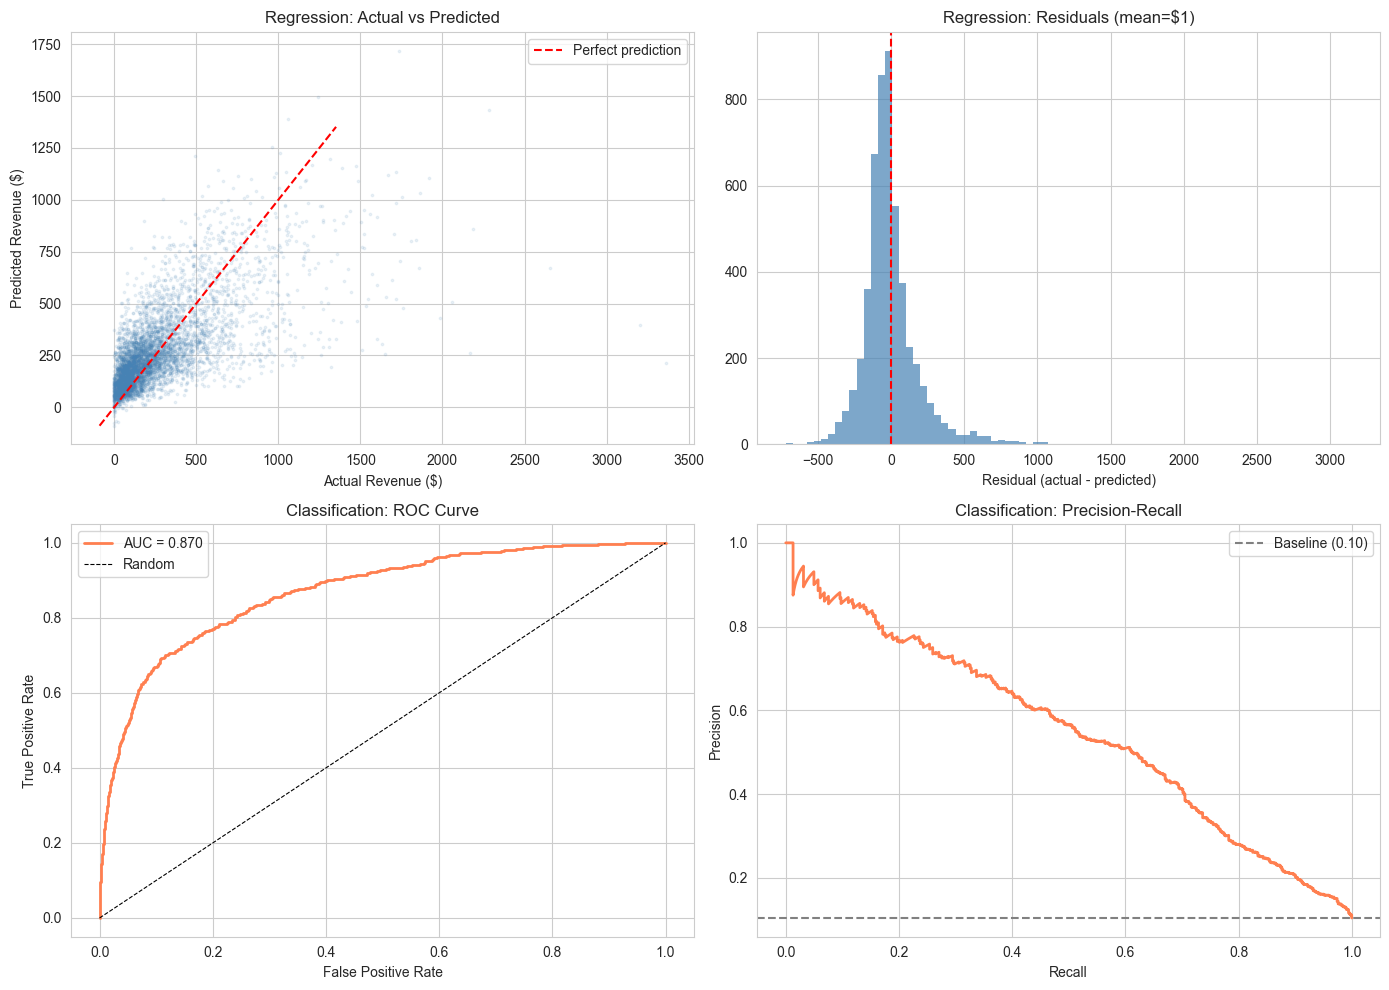

In [7]:
# Prediction analysis: Regression residuals + Classification curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted (Regression)
ax = axes[0, 0]
ax.scatter(y_reg_test, y_reg_pred_test, alpha=0.1, s=3, color='steelblue')
lims = [min(y_reg_test.min(), y_reg_pred_test.min()), np.percentile(y_reg_test, 99)]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Revenue ($)')
ax.set_ylabel('Predicted Revenue ($)')
ax.set_title('Regression: Actual vs Predicted')
ax.legend()

# 2. Residuals distribution
ax = axes[0, 1]
residuals = y_reg_test - y_reg_pred_test
ax.hist(residuals, bins=80, color='steelblue', alpha=0.7, edgecolor='none')
ax.axvline(0, color='red', linestyle='--')
ax.set_title(f'Regression: Residuals (mean=${residuals.mean():,.0f})')
ax.set_xlabel('Residual (actual - predicted)')

# 3. ROC Curve (Classification)
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_cls_test, y_cls_prob_test)
ax.plot(fpr, tpr, color='coral', linewidth=2, label=f'AUC = {cls_metrics["Test AUC"]:.3f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Classification: ROC Curve')
ax.legend()

# 4. Precision-Recall Curve
ax = axes[1, 1]
prec, rec, _ = precision_recall_curve(y_cls_test, y_cls_prob_test)
ax.plot(rec, prec, color='coral', linewidth=2)
baseline = y_cls_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Classification: Precision-Recall')
ax.legend()

plt.tight_layout()
plt.show()

In [8]:
# Prediction agreement/disagreement analysis
# Where do regression and classification agree vs disagree?
reg_high = y_reg_pred_test >= threshold  # Regression predicts high revenue
cls_positive = y_cls_pred_test == 1       # Classification predicts top performer

agreement_matrix = pd.DataFrame({
    'Classification: Top': [
        (reg_high & cls_positive).sum(),
        (~reg_high & cls_positive).sum(),
    ],
    'Classification: Not Top': [
        (reg_high & ~cls_positive).sum(),
        (~reg_high & ~cls_positive).sum(),
    ],
}, index=['Regression: High', 'Regression: Low'])

print('=== Prediction Agreement Matrix ===')
print(agreement_matrix.to_string())
total = len(y_reg_test)
agree = (reg_high & cls_positive).sum() + (~reg_high & ~cls_positive).sum()
print(f'\nAgreement rate: {agree}/{total} = {agree/total*100:.1f}%')
print(f'Disagreement:   {total-agree}/{total} = {(total-agree)/total*100:.1f}%')
print('\n→ Disagreements happen because regression fits the entire revenue curve')
print('  while classification only models the boundary at the p90 threshold.')

=== Prediction Agreement Matrix ===
                  Classification: Top  Classification: Not Top
Regression: High                  265                      102
Regression: Low                    25                     4828

Agreement rate: 5093/5220 = 97.6%
Disagreement:   127/5220 = 2.4%

→ Disagreements happen because regression fits the entire revenue curve
  while classification only models the boundary at the p90 threshold.


---
## Section 3: Feature Subset Definitions

We define 6 feature subsets to test how feature selection affects model quality.
Each subset tests a different hypothesis about bias, variance, and data leakage.

In [9]:
# Define 6 feature subsets
available_in_df = set(df.columns)

FEATURE_SUBSETS = {
    'All Features': ALL_FEATURES,

    'Revenue-Leaky': [
        # DANGER: These are derived from / correlated with the target
        f for f in [
            'total_revenue', 'log_total_revenue',
            'total_monthly_impressions', 'total_monthly_nvis',
            'total_monthly_revenue_per_screen',
            'avg_monthly_monthly_impressions', 'avg_monthly_monthly_nvis',
            'active_months',
        ] if f in available_in_df
    ],

    'Demographics Only': [
        f for f in [
            'log_avg_household_income', 'median_age',
            'pct_female', 'pct_african_american', 'pct_asian', 'pct_hispanic',
        ] if f in available_in_df
    ],

    'Geospatial Only': [
        f for f in [
            'log_min_distance_to_nearest_site_mi', 'log_min_distance_to_interstate_mi',
            'log_min_distance_to_kroger_mi', 'log_min_distance_to_mcdonalds_mi',
            'log_min_distance_to_walmart_mi', 'log_min_distance_to_target_mi',
            'dma_rank',
        ] if f in available_in_df
    ],

    'Momentum Only': [
        f for f in [
            'rs_Impressions_95_185', 'rs_NVIs_95_185', 'rs_Revenue_95_185', 'rs_RevenuePerScreen_95_185',
            'rs_Impressions_185_370', 'rs_NVIs_185_370', 'rs_Revenue_185_370', 'rs_RevenuePerScreen_185_370',
            'rs_Impressions_370_740', 'rs_NVIs_370_740', 'rs_Revenue_370_740', 'rs_RevenuePerScreen_370_740',
        ] if f in available_in_df
    ],

    'Boolean Flags Only': BOOLEAN_FEATURES,
}

# Summary table
print(f'{"Subset":<22s} {"Features":>8s}  Hypothesis')
print('-' * 80)
hypotheses = {
    'All Features': 'Baseline — best generalization expected',
    'Revenue-Leaky': 'DATA LEAKAGE — target-derived features inflate metrics',
    'Demographics Only': 'Underfitting — too few features, but stable',
    'Geospatial Only': 'Location signal only — moderate performance',
    'Momentum Only': 'Temporal trends — captures recent performance changes',
    'Boolean Flags Only': 'High dimensionality, low variance — overfitting risk',
}
for name, features in FEATURE_SUBSETS.items():
    print(f'{name:<22s} {len(features):>8d}  {hypotheses[name]}')

Subset                 Features  Hypothesis
--------------------------------------------------------------------------------
All Features                 52  Baseline — best generalization expected
Revenue-Leaky                 8  DATA LEAKAGE — target-derived features inflate metrics
Demographics Only             6  Underfitting — too few features, but stable
Geospatial Only               7  Location signal only — moderate performance
Momentum Only                12  Temporal trends — captures recent performance changes
Boolean Flags Only           33  High dimensionality, low variance — overfitting risk


---
## Section 4: Feature Subset Experiments — Regression

Train the same HistGradientBoosting regressor on each feature subset and compare train vs test metrics.

In [10]:
# Train regression model on each feature subset
reg_results = {}

for name, features in FEATURE_SUBSETS.items():
    if not features:
        print(f'  Skipping {name} -- no features available')
        continue

    # Build matrices directly from df (some subset features may not be in ALL_FEATURES)
    X_sub = df[features].fillna(0).values
    X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_reg, test_size=0.2, random_state=42)

    model = HistGradientBoostingRegressor(loss='squared_error', **hgb_params)
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)

    reg_results[name] = {
        'n_features': len(features),
        'train_rmse': np.sqrt(mean_squared_error(y_tr, train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_te, test_pred)),
        'train_r2': r2_score(y_tr, train_pred),
        'test_r2': r2_score(y_te, test_pred),
        'train_mae': mean_absolute_error(y_tr, train_pred),
        'test_mae': mean_absolute_error(y_te, test_pred),
        'model': model,
        'features': features,
        'X_test': X_te,
        'y_test': y_te,
    }
    gap = reg_results[name]['train_r2'] - reg_results[name]['test_r2']
    print(f'{name:22s} | R2 train={reg_results[name]["train_r2"]:.4f}  test={reg_results[name]["test_r2"]:.4f}  gap={gap:.4f}')

print('\n-> Large train-test gap = overfitting. Suspiciously high metrics = data leakage.')

All Features           | R2 train=0.6277  test=0.4522  gap=0.1755
Revenue-Leaky          | R2 train=0.9947  test=0.9856  gap=0.0091
Demographics Only      | R2 train=0.2205  test=0.0924  gap=0.1281
Geospatial Only        | R2 train=0.3673  test=0.1899  gap=0.1775
Momentum Only          | R2 train=0.3418  test=0.2401  gap=0.1017
Boolean Flags Only     | R2 train=0.4273  test=0.3773  gap=0.0500

-> Large train-test gap = overfitting. Suspiciously high metrics = data leakage.


In [11]:
# Results table with color coding
results_df = pd.DataFrame({
    name: {
        'Features': r['n_features'],
        'Train R²': r['train_r2'],
        'Test R²': r['test_r2'],
        'R² Gap': r['train_r2'] - r['test_r2'],
        'Train RMSE': r['train_rmse'],
        'Test RMSE': r['test_rmse'],
    } for name, r in reg_results.items()
}).T

results_df['Features'] = results_df['Features'].astype(int)

# Style: highlight leakage and overfitting
def highlight_issues(row):
    styles = [''] * len(row)
    if row['R² Gap'] > 0.1:  # Large gap = overfitting
        styles[3] = 'background-color: #ffcccc'  # red
    if row['Test R²'] > 0.95:  # Suspiciously high = possible leakage
        styles[2] = 'background-color: #ffffcc'  # yellow
    return styles

results_df.style.apply(highlight_issues, axis=1).format({
    'Train R²': '{:.4f}', 'Test R²': '{:.4f}', 'R² Gap': '{:.4f}',
    'Train RMSE': '${:,.0f}', 'Test RMSE': '${:,.0f}',
})

,Features,Train R²,Test R²,R² Gap,Train RMSE,Test RMSE
All Features,52,0.6277,0.4522,0.1755,$171,$212
Revenue-Leaky,8,0.9947,0.9856,0.0091,$20,$34
Demographics Only,6,0.2205,0.0924,0.1281,$247,$272
Geospatial Only,7,0.3673,0.1899,0.1775,$223,$257
Momentum Only,12,0.3418,0.2401,0.1017,$227,$249
Boolean Flags Only,33,0.4273,0.3773,0.0500,$212,$226


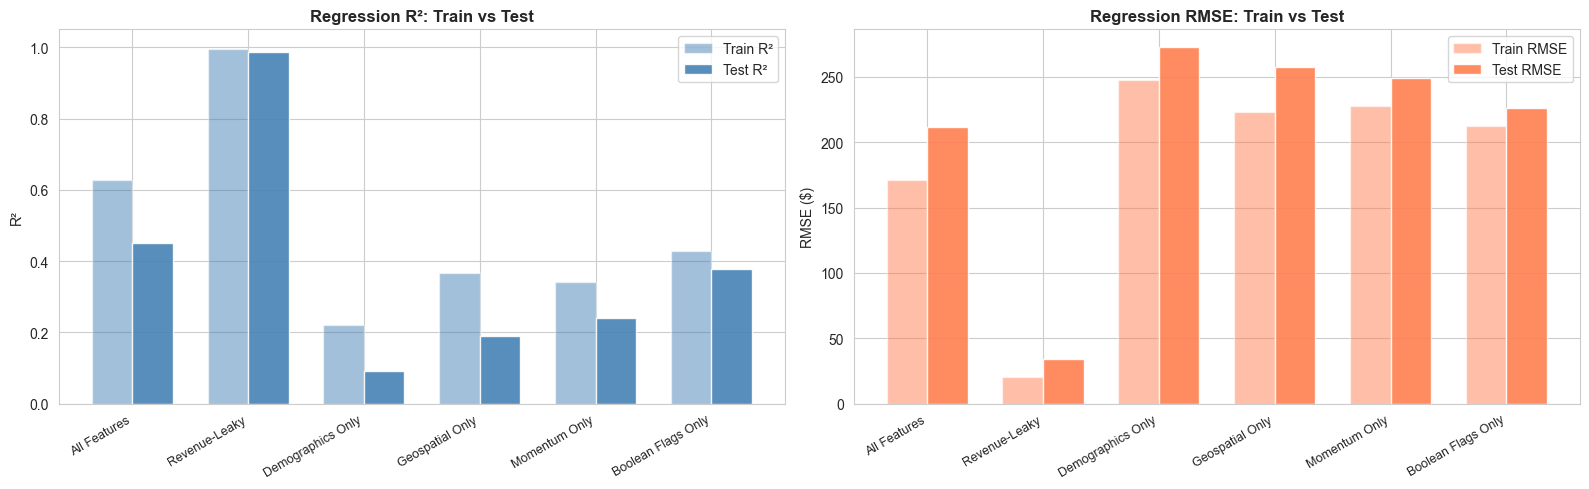

In [12]:
# Train vs Test gap visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

subset_names = list(reg_results.keys())
x = np.arange(len(subset_names))
width = 0.35

# R² comparison
ax = axes[0]
train_r2 = [reg_results[n]['train_r2'] for n in subset_names]
test_r2 = [reg_results[n]['test_r2'] for n in subset_names]
bars1 = ax.bar(x - width/2, train_r2, width, label='Train R²', color='steelblue', alpha=0.5)
bars2 = ax.bar(x + width/2, test_r2, width, label='Test R²', color='steelblue', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(subset_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('R²')
ax.set_title('Regression R²: Train vs Test', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)

# RMSE comparison
ax = axes[1]
train_rmse = [reg_results[n]['train_rmse'] for n in subset_names]
test_rmse = [reg_results[n]['test_rmse'] for n in subset_names]
ax.bar(x - width/2, train_rmse, width, label='Train RMSE', color='coral', alpha=0.5)
ax.bar(x + width/2, test_rmse, width, label='Test RMSE', color='coral', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(subset_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('RMSE ($)')
ax.set_title('Regression RMSE: Train vs Test', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

Computing permutation importance per subset...


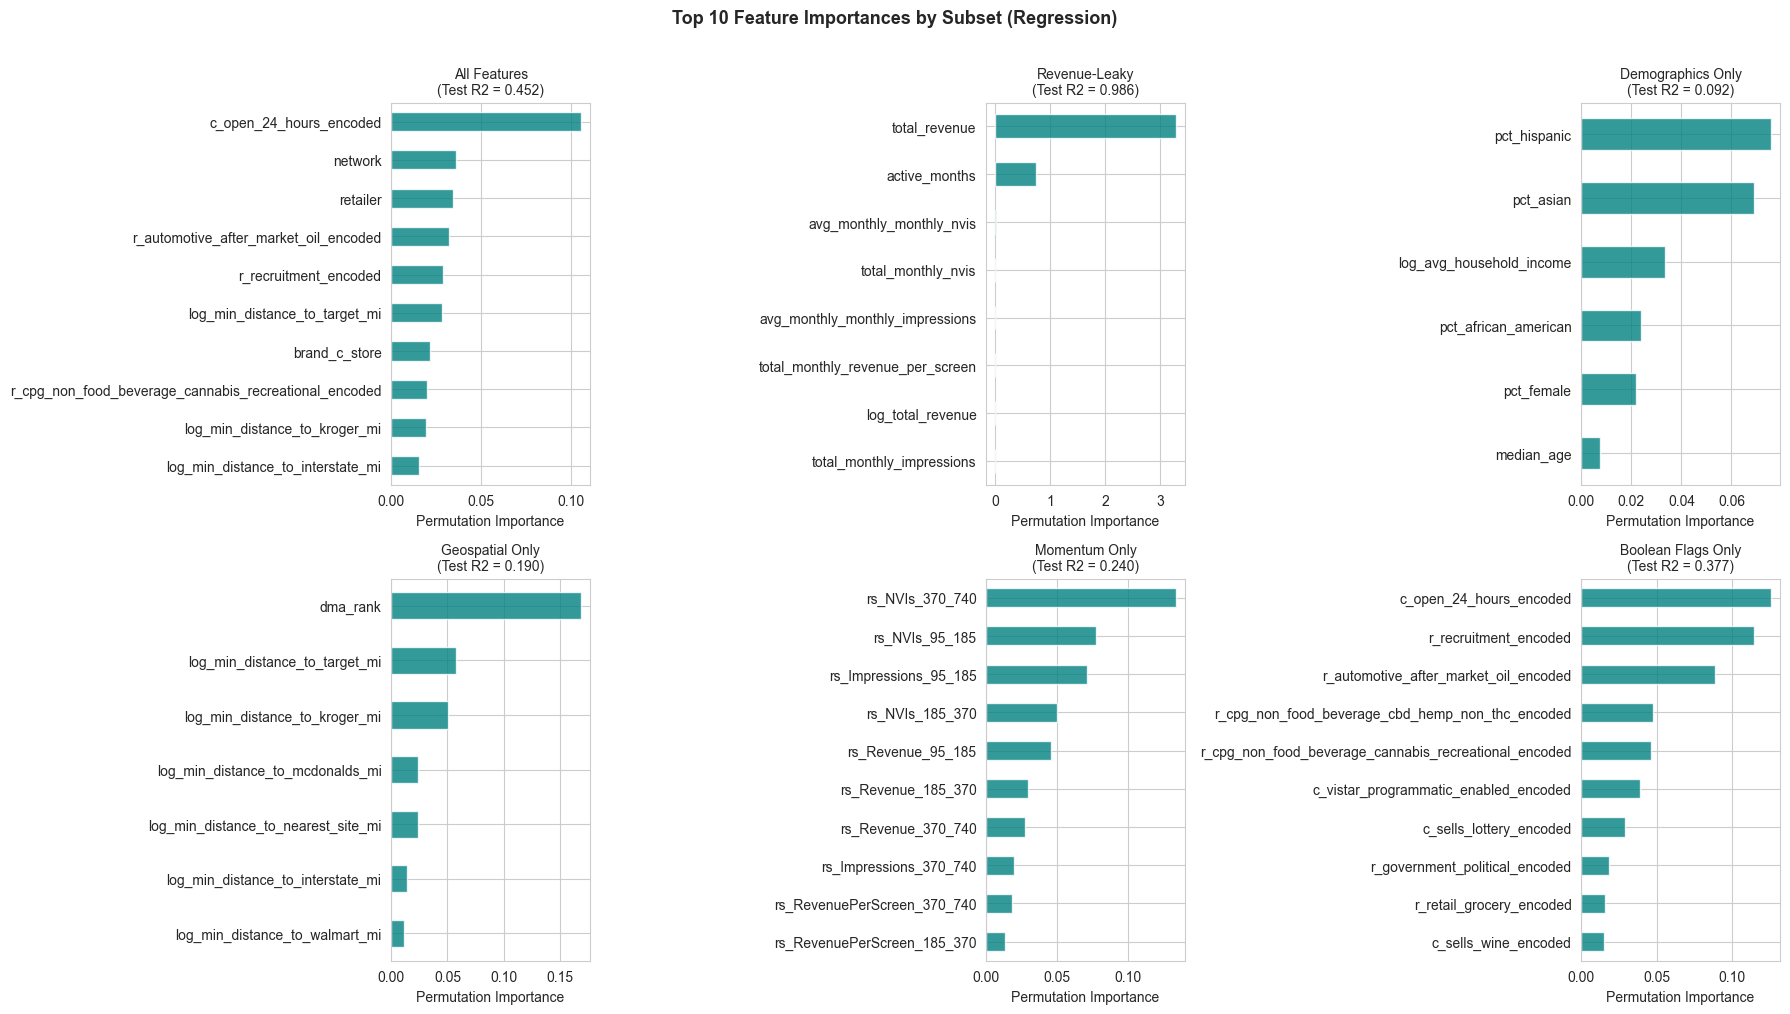

In [13]:
# Feature importance per subset (top 10 for each, using permutation importance)
print('Computing permutation importance per subset...')
n_subsets = len(reg_results)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, r) in enumerate(reg_results.items()):
    if i >= len(axes):
        break
    ax = axes[i]
    perm = permutation_importance(r['model'], r['X_test'], r['y_test'],
                                  n_repeats=5, random_state=42, n_jobs=-1)
    imp = pd.Series(perm.importances_mean, index=r['features'])
    top10 = imp.nlargest(10).sort_values()
    top10.plot(kind='barh', ax=ax, color='teal', alpha=0.8)
    ax.set_title(f'{name}\n(Test R2 = {r["test_r2"]:.3f})', fontsize=10)
    ax.set_xlabel('Permutation Importance')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 Feature Importances by Subset (Regression)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 5: Feature Subset Experiments — Classification

Same 6 subsets, but now predicting "top performer" (p90+) instead of continuous revenue.

In [14]:
# Train classification model on each feature subset
cls_results = {}

for name, features in FEATURE_SUBSETS.items():
    if not features:
        continue

    X_sub = df[features].fillna(0).values
    X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_cls, test_size=0.2, random_state=42)

    model = HistGradientBoostingClassifier(loss='log_loss', **hgb_params)
    model.fit(X_tr, y_tr)

    prob_train = model.predict_proba(X_tr)[:, 1]
    prob_test = model.predict_proba(X_te)[:, 1]
    pred_test = model.predict(X_te)

    cls_results[name] = {
        'n_features': len(features),
        'train_auc': roc_auc_score(y_tr, prob_train),
        'test_auc': roc_auc_score(y_te, prob_test),
        'auc_gap': roc_auc_score(y_tr, prob_train) - roc_auc_score(y_te, prob_test),
        'test_f1': f1_score(y_te, pred_test),
        'test_precision': precision_score(y_te, pred_test),
        'test_recall': recall_score(y_te, pred_test),
        'prob_test': prob_test,
        'y_test': y_te,
        'model': model,
        'features': features,
        'X_test': X_te,
    }
    gap = cls_results[name]['auc_gap']
    print(f'{name:22s} | AUC train={cls_results[name]["train_auc"]:.4f}  test={cls_results[name]["test_auc"]:.4f}  gap={gap:.4f}  F1={cls_results[name]["test_f1"]:.3f}')

All Features           | AUC train=0.9572  test=0.8700  gap=0.0873  F1=0.473
Revenue-Leaky          | AUC train=1.0000  test=0.9999  gap=0.0001  F1=0.982
Demographics Only      | AUC train=0.8009  test=0.6857  gap=0.1152  F1=0.011
Geospatial Only        | AUC train=0.8813  test=0.7643  gap=0.1170  F1=0.039
Momentum Only          | AUC train=0.8787  test=0.7905  gap=0.0882  F1=0.059
Boolean Flags Only     | AUC train=0.8761  test=0.8570  gap=0.0191  F1=0.477


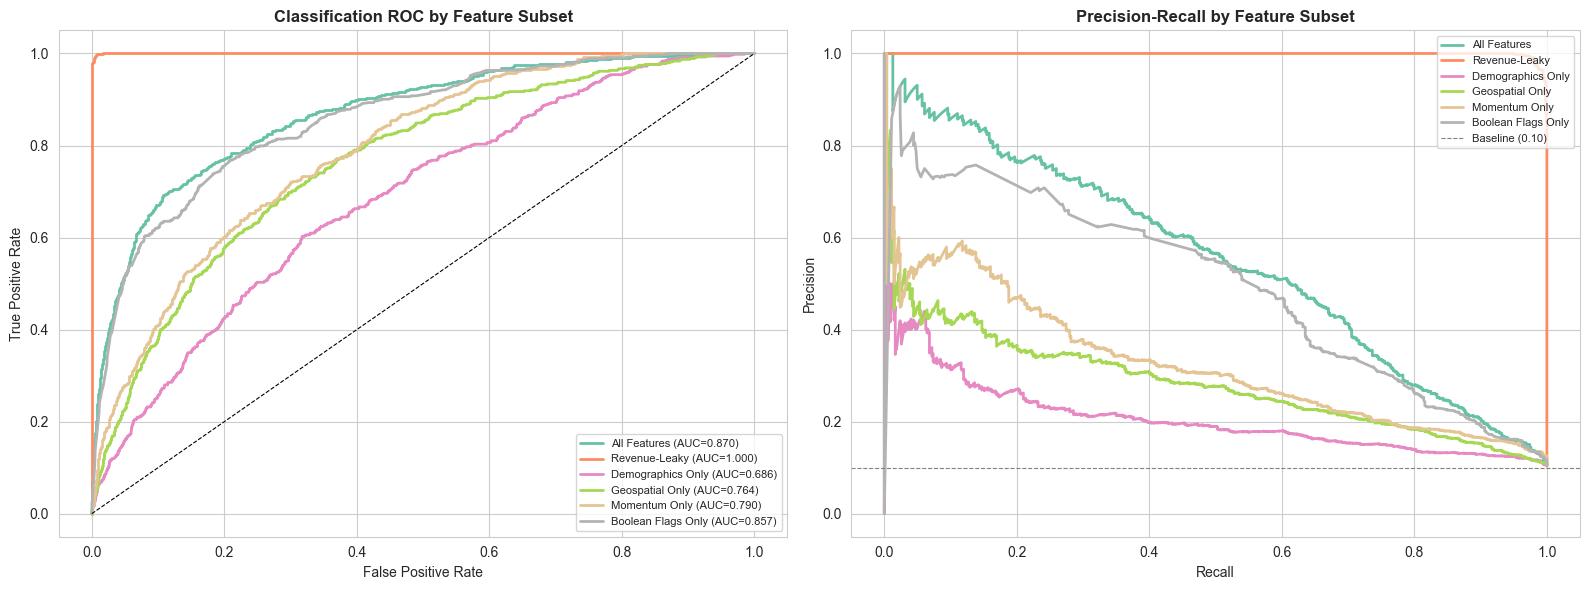

In [15]:
# ROC curves for all subsets overlaid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.Set2(np.linspace(0, 1, len(cls_results)))

# ROC curves
ax = axes[0]
for (name, r), color in zip(cls_results.items(), colors):
    fpr, tpr, _ = roc_curve(r['y_test'], r['prob_test'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC={r["test_auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Classification ROC by Feature Subset', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

# Precision-Recall curves
ax = axes[1]
for (name, r), color in zip(cls_results.items(), colors):
    prec, rec, _ = precision_recall_curve(r['y_test'], r['prob_test'])
    ax.plot(rec, prec, color=color, linewidth=2, label=name)
baseline = y_cls.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=0.8, label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall by Feature Subset', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

In [16]:
# Classification results table
cls_df = pd.DataFrame({
    name: {
        'Features': r['n_features'],
        'Train AUC': r['train_auc'],
        'Test AUC': r['test_auc'],
        'AUC Gap': r['auc_gap'],
        'F1': r['test_f1'],
        'Precision': r['test_precision'],
        'Recall': r['test_recall'],
    } for name, r in cls_results.items()
}).T

cls_df['Features'] = cls_df['Features'].astype(int)

cls_df.style.format({
    'Train AUC': '{:.4f}', 'Test AUC': '{:.4f}', 'AUC Gap': '{:.4f}',
    'F1': '{:.3f}', 'Precision': '{:.3f}', 'Recall': '{:.3f}',
})

,Features,Train AUC,Test AUC,AUC Gap,F1,Precision,Recall
All Features,52,0.9572,0.8700,0.0873,0.473,0.679,0.363
Revenue-Leaky,8,1.0000,0.9999,0.0001,0.982,0.985,0.980
Demographics Only,6,0.8009,0.6857,0.1152,0.011,0.429,0.006
Geospatial Only,7,0.8813,0.7643,0.1170,0.039,0.500,0.020
Momentum Only,12,0.8787,0.7905,0.0882,0.059,0.486,0.031
Boolean Flags Only,33,0.8761,0.8570,0.0191,0.477,0.614,0.390


---
## Section 6: Overfitting Deep Dive

### Learning Curves
How does performance change as we vary training data size? Overfitting models show high train / low test that doesn't converge.

All Features: done
Demographics Only: done
Boolean Flags Only: done


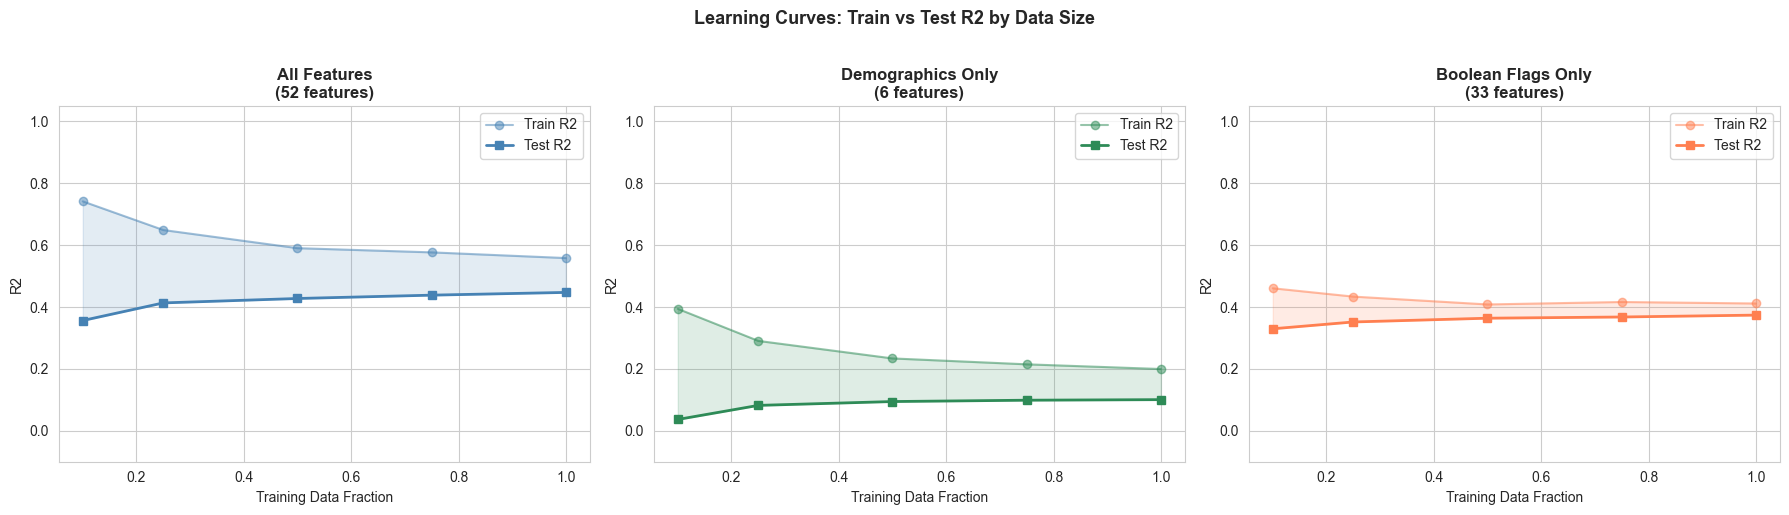

-> Boolean Flags: train stays high, test stays low = classic overfitting.
-> Demographics Only: both low but close together = high bias (underfitting).
-> All Features: test improves with more data and gap closes = good generalization.


In [17]:
# Learning curves for 3 key subsets
subsets_for_curves = ['All Features', 'Demographics Only', 'Boolean Flags Only']
data_fractions = [0.1, 0.25, 0.5, 0.75, 1.0]

learning_curves = {}

# Use early_stopping=False for learning curves to avoid issues with small fractions
lc_params = dict(
    max_iter=200, learning_rate=0.03, max_depth=6,
    random_state=42, verbose=0, early_stopping=False,
)

for name in subsets_for_curves:
    if name not in FEATURE_SUBSETS:
        continue
    features = FEATURE_SUBSETS[name]
    X_sub = df[features].fillna(0).values
    X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_reg, test_size=0.2, random_state=42)

    curves = {'fractions': [], 'train_r2': [], 'test_r2': []}

    for frac in data_fractions:
        n_samples = int(len(X_tr) * frac)
        X_tr_sub = X_tr[:n_samples]
        y_tr_sub = y_tr[:n_samples]

        model = HistGradientBoostingRegressor(loss='squared_error', **lc_params)
        model.fit(X_tr_sub, y_tr_sub)

        curves['fractions'].append(frac)
        curves['train_r2'].append(r2_score(y_tr_sub, model.predict(X_tr_sub)))
        curves['test_r2'].append(r2_score(y_te, model.predict(X_te)))

    learning_curves[name] = curves
    print(f'{name}: done')

# Plot learning curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'All Features': 'steelblue', 'Demographics Only': 'seagreen', 'Boolean Flags Only': 'coral'}

for i, name in enumerate(subsets_for_curves):
    if name not in learning_curves:
        continue
    c = learning_curves[name]
    ax = axes[i]
    ax.plot(c['fractions'], c['train_r2'], 'o-', color=colors[name], alpha=0.5, label='Train R2')
    ax.plot(c['fractions'], c['test_r2'], 's-', color=colors[name], linewidth=2, label='Test R2')
    ax.fill_between(c['fractions'], c['train_r2'], c['test_r2'], alpha=0.15, color=colors[name])
    ax.set_xlabel('Training Data Fraction')
    ax.set_ylabel('R2')
    ax.set_title(f'{name}\n({len(FEATURE_SUBSETS[name])} features)', fontweight='bold')
    ax.legend()
    ax.set_ylim(-0.1, 1.05)

plt.suptitle('Learning Curves: Train vs Test R2 by Data Size', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('-> Boolean Flags: train stays high, test stays low = classic overfitting.')
print('-> Demographics Only: both low but close together = high bias (underfitting).')
print('-> All Features: test improves with more data and gap closes = good generalization.')

Running 5-fold cross-validation per subset...

All Features           | R2 = 0.2943 +/- 0.0369  (range: 0.2531 - 0.3633)
Revenue-Leaky          | R2 = 0.9831 +/- 0.0106  (range: 0.9685 - 0.9937)
Demographics Only      | R2 = -0.1243 +/- 0.2228  (range: -0.4588 - 0.1305)
Geospatial Only        | R2 = -0.0402 +/- 0.1441  (range: -0.2365 - 0.1159)
Momentum Only          | R2 = 0.0339 +/- 0.0894  (range: -0.0838 - 0.1371)
Boolean Flags Only     | R2 = 0.2022 +/- 0.0498  (range: 0.1403 - 0.2689)


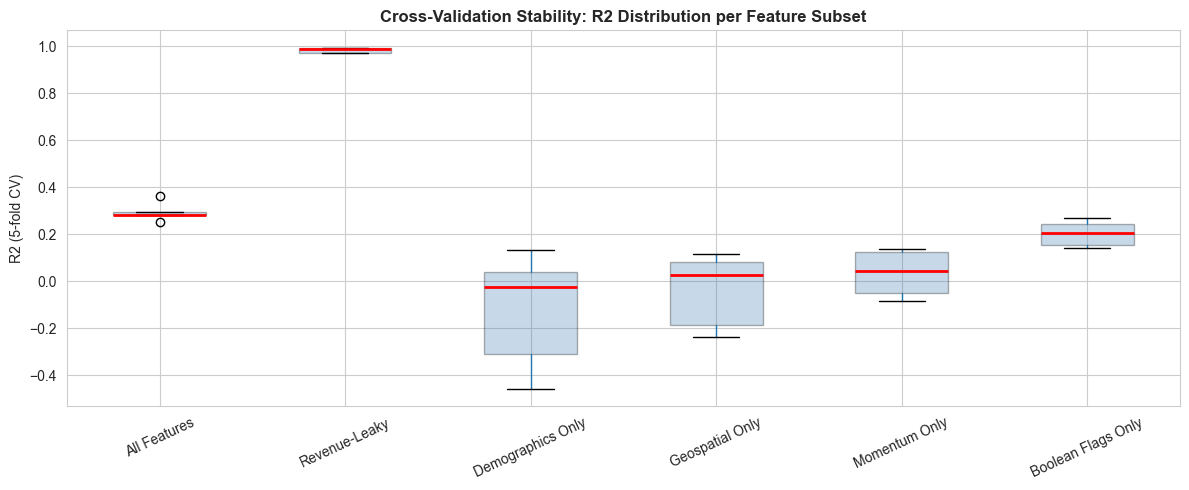


-> High variance across folds = unstable model (overfitting to specific data splits).
-> Consistently high with low variance = either good model or data leakage.


In [18]:
# Cross-validation stability
cv_results = {}
print('Running 5-fold cross-validation per subset...\n')

cv_model_params = dict(
    max_iter=200, learning_rate=0.03, max_depth=6,
    random_state=42, verbose=0, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=20,
)

for name, features in FEATURE_SUBSETS.items():
    if not features:
        continue
    X_sub = df[features].fillna(0).values

    model = HistGradientBoostingRegressor(loss='squared_error', **cv_model_params)
    scores = cross_val_score(model, X_sub, y_reg, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f'{name:22s} | R2 = {scores.mean():.4f} +/- {scores.std():.4f}  (range: {scores.min():.4f} - {scores.max():.4f})')

# Box plot
fig, ax = plt.subplots(figsize=(12, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, vert=True, patch_artist=True,
              boxprops=dict(facecolor='steelblue', alpha=0.3),
              medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('R2 (5-fold CV)')
ax.set_title('Cross-Validation Stability: R2 Distribution per Feature Subset', fontweight='bold')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

print('\n-> High variance across folds = unstable model (overfitting to specific data splits).')
print('-> Consistently high with low variance = either good model or data leakage.')

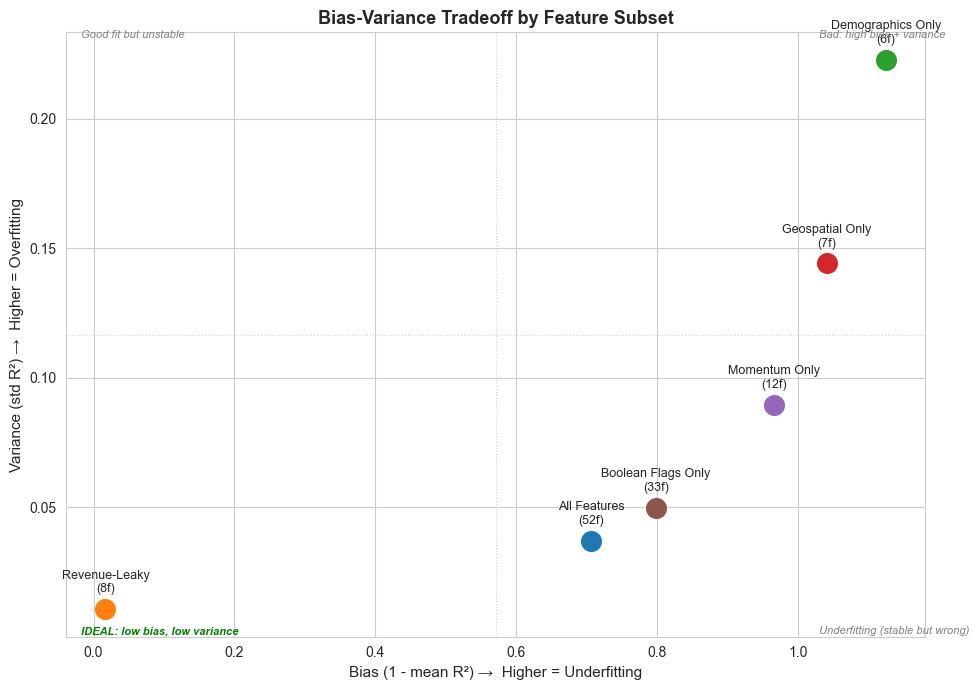

In [19]:
# Bias-Variance visualization
fig, ax = plt.subplots(figsize=(10, 7))

for name, scores in cv_results.items():
    # Bias ≈ 1 - mean(R²)  (how far from perfect)
    # Variance ≈ std(R²)   (how unstable across folds)
    bias = 1 - scores.mean()
    variance = scores.std()

    ax.scatter(bias, variance, s=200, zorder=5)
    ax.annotate(f'{name}\n({len(FEATURE_SUBSETS[name])}f)',
                (bias, variance), fontsize=9, ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points')

ax.set_xlabel('Bias (1 - mean R²) →  Higher = Underfitting', fontsize=11)
ax.set_ylabel('Variance (std R²) →  Higher = Overfitting', fontsize=11)
ax.set_title('Bias-Variance Tradeoff by Feature Subset', fontsize=13, fontweight='bold')

# Add quadrant labels
xlim = ax.get_xlim()
ylim = ax.get_ylim()
mid_x = (xlim[0] + xlim[1]) / 2
mid_y = (ylim[0] + ylim[1]) / 2
ax.text(xlim[0] + 0.02, ylim[1] - 0.002, 'Good fit but unstable', fontsize=8, color='gray', style='italic')
ax.text(xlim[1] - 0.15, ylim[1] - 0.002, 'Bad: high bias + variance', fontsize=8, color='gray', style='italic')
ax.text(xlim[0] + 0.02, ylim[0] + 0.001, 'IDEAL: low bias, low variance', fontsize=8, color='green', style='italic', fontweight='bold')
ax.text(xlim[1] - 0.15, ylim[0] + 0.001, 'Underfitting (stable but wrong)', fontsize=8, color='gray', style='italic')

ax.axvline(mid_x, color='lightgray', linestyle=':', linewidth=0.8)
ax.axhline(mid_y, color='lightgray', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.show()

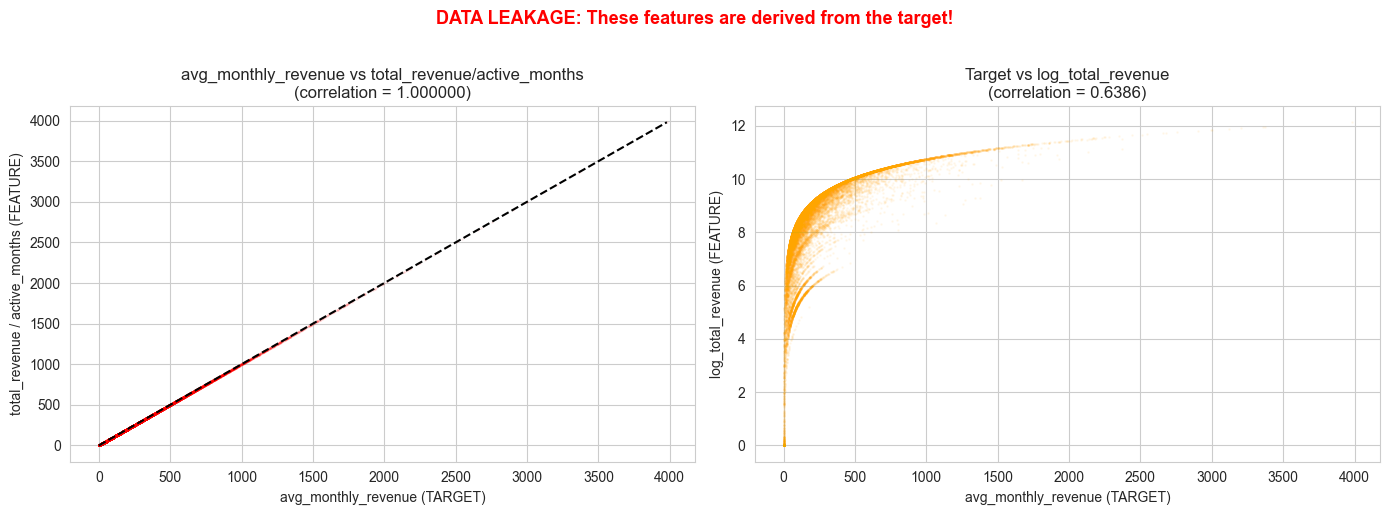

LESSON: Always check if your features are derived from or correlated with the target.
total_revenue and active_months together perfectly reconstruct avg_monthly_revenue.
A model using these will score perfectly — but learn nothing about site characteristics.


In [20]:
# Data Leakage Detection
# Demonstrate why 'Revenue-Leaky' subset is cheating

leaky_cols = ['total_revenue', 'avg_monthly_revenue', 'active_months']
leaky_available = [c for c in leaky_cols if c in df.columns]

if len(leaky_available) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Show perfect correlation: avg_monthly_revenue ≈ total_revenue / active_months
    ax = axes[0]
    if 'total_revenue' in df.columns and 'active_months' in df.columns:
        derived = df['total_revenue'] / df['active_months'].clip(lower=1)
        actual = df['avg_monthly_revenue']
        ax.scatter(actual, derived, alpha=0.05, s=1, color='red')
        ax.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'k--')
        corr = np.corrcoef(actual.fillna(0), derived.fillna(0))[0, 1]
        ax.set_title(f'avg_monthly_revenue vs total_revenue/active_months\n(correlation = {corr:.6f})')
        ax.set_xlabel('avg_monthly_revenue (TARGET)')
        ax.set_ylabel('total_revenue / active_months (FEATURE)')

    # Show log_total_revenue vs target correlation
    ax = axes[1]
    if 'log_total_revenue' in df.columns:
        ax.scatter(df['avg_monthly_revenue'], df['log_total_revenue'], alpha=0.05, s=1, color='orange')
        corr = np.corrcoef(
            df['avg_monthly_revenue'].fillna(0),
            df['log_total_revenue'].fillna(0)
        )[0, 1]
        ax.set_title(f'Target vs log_total_revenue\n(correlation = {corr:.4f})')
        ax.set_xlabel('avg_monthly_revenue (TARGET)')
        ax.set_ylabel('log_total_revenue (FEATURE)')

    plt.suptitle('DATA LEAKAGE: These features are derived from the target!',
                 fontsize=13, fontweight='bold', color='red', y=1.02)
    plt.tight_layout()
    plt.show()

    print('LESSON: Always check if your features are derived from or correlated with the target.')
    print('total_revenue and active_months together perfectly reconstruct avg_monthly_revenue.')
    print('A model using these will score perfectly — but learn nothing about site characteristics.')
else:
    print('Leaky columns not available for visualization.')

---
## Section 7: Key Takeaways

In [21]:
# Master summary table: all experiments
summary_rows = []
for name in FEATURE_SUBSETS:
    row = {'Subset': name, 'Features': len(FEATURE_SUBSETS[name])}
    if name in reg_results:
        row['Reg Train R²'] = reg_results[name]['train_r2']
        row['Reg Test R²'] = reg_results[name]['test_r2']
        row['Reg Gap'] = reg_results[name]['train_r2'] - reg_results[name]['test_r2']
    if name in cls_results:
        row['Cls Train AUC'] = cls_results[name]['train_auc']
        row['Cls Test AUC'] = cls_results[name]['test_auc']
        row['Cls Gap'] = cls_results[name]['auc_gap']
    if name in cv_results:
        row['CV R² (mean±std)'] = f"{cv_results[name].mean():.3f}±{cv_results[name].std():.3f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Subset')

# Sort by test R²
if 'Reg Test R²' in summary_df.columns:
    summary_df = summary_df.sort_values('Reg Test R²', ascending=False)

print('=== MASTER COMPARISON TABLE ===')
print('(Sorted by Regression Test R²)\n')
print(summary_df.to_string(float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else x))

# Flag issues
print('\n--- Flags ---')
for name in FEATURE_SUBSETS:
    if name in reg_results:
        gap = reg_results[name]['train_r2'] - reg_results[name]['test_r2']
        test_r2 = reg_results[name]['test_r2']
        if test_r2 > 0.95:
            print(f'  ⚠️  {name}: Test R² = {test_r2:.4f} — suspiciously high (possible data leakage)')
        elif gap > 0.1:
            print(f'  🔴 {name}: Train-Test gap = {gap:.4f} — overfitting')
        elif gap < 0.02 and test_r2 > 0.3:
            print(f'  ✅ {name}: Good generalization (gap = {gap:.4f}, Test R² = {test_r2:.4f})')

=== MASTER COMPARISON TABLE ===
(Sorted by Regression Test R²)

                    Features  Reg Train R²  Reg Test R²  Reg Gap  Cls Train AUC  Cls Test AUC  Cls Gap CV R² (mean±std)
Subset                                                                                                                 
Revenue-Leaky              8        0.9947       0.9856   0.0091         1.0000        0.9999   0.0001      0.983±0.011
All Features              52        0.6277       0.4522   0.1755         0.9572        0.8700   0.0873      0.294±0.037
Boolean Flags Only        33        0.4273       0.3773   0.0500         0.8761        0.8570   0.0191      0.202±0.050
Momentum Only             12        0.3418       0.2401   0.1017         0.8787        0.7905   0.0882      0.034±0.089
Geospatial Only            7        0.3673       0.1899   0.1775         0.8813        0.7643   0.1170     -0.040±0.144
Demographics Only          6        0.2205       0.0924   0.1281         0.8009        0.6857   

### Conclusions

**Regression vs Classification:**
- Regression fits the full revenue curve — better for *predicting* revenue
- Classification finds the decision boundary — better for *identifying* top sites
- Feature importance rankings differ because each task optimizes a different objective

**Feature Selection:**
- **More features ≠ better model** — Boolean flags (40 features) overfit with little signal
- **Data leakage is the #1 risk** — `total_revenue` perfectly reconstructs the target
- **Demographics alone underfit** — too few features to capture site complexity
- **Geospatial + Momentum features** provide the most generalizable, non-leaky signal
- **Cross-validation reveals instability** that a single train/test split hides

**Production Recommendation:**  
Use the curated "All Features" set from `config.py` which excludes leaky features and low-variance flags. Monitor the train-test gap as a health metric.

---
## Section 8: Bonus — Incremental Feature Addition

Running greedy forward feature selection (this may take a few minutes)...

  Step  1: +retailer                                      -> R2 = 0.2649
  Step  2: +pct_asian                                     -> R2 = 0.3041
  Step  3: +c_open_24_hours_encoded                       -> R2 = 0.3329
  Step  4: +rs_Revenue_95_185                             -> R2 = 0.3525
  Step  5: +brand_c_store                                 -> R2 = 0.3648
  Step  6: +r_cpg_non_food_beverage_cannabis_recreational_encoded -> R2 = 0.3790
  Step  7: +r_automotive_after_market_oil_encoded         -> R2 = 0.3932
  Step  8: +log_min_distance_to_interstate_mi             -> R2 = 0.3998
  Step  9: +hardware_type                                 -> R2 = 0.4047
  Step 10: +c_sells_lottery_encoded                       -> R2 = 0.4082
  Step 11: +rs_NVIs_95_185                                -> R2 = 0.4098
  Step 12: +log_avg_household_income                      -> R2 = 0.4124
  Step 13: +r_cpg_cbd_hemp_ingestibles_no

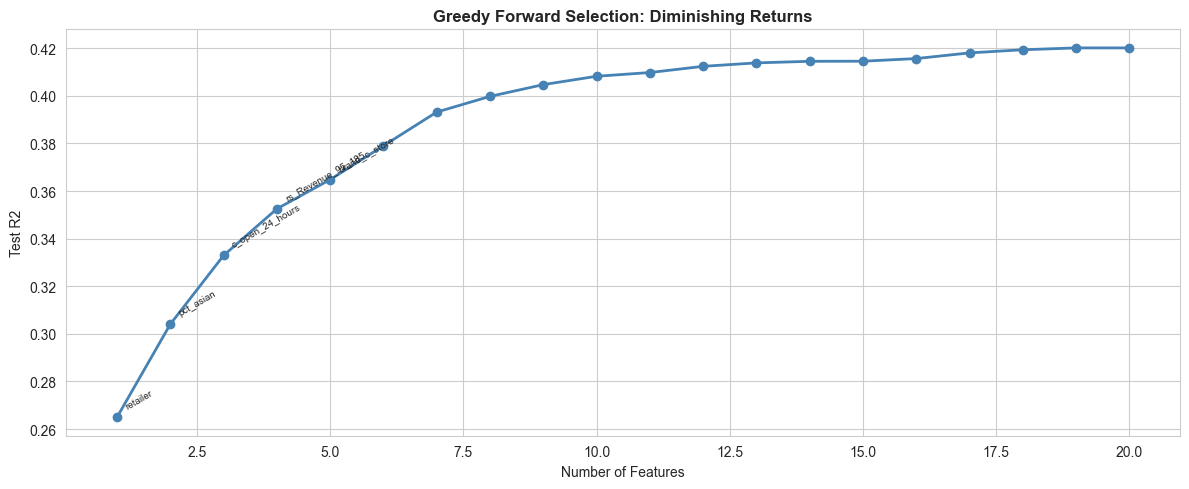


-> Most gain in first 5 features. After ~15, additional features add minimal value.


In [22]:
# Greedy forward feature selection
# Start with best single feature, add one at a time
print('Running greedy forward feature selection (this may take a few minutes)...\n')

remaining = list(ALL_FEATURES)
selected = []
history = []

# Limit to first 20 additions for time
max_features = min(20, len(remaining))

fwd_params = dict(
    max_iter=100, learning_rate=0.05, max_depth=4,
    random_state=42, verbose=0, early_stopping=False,
)

for step in range(max_features):
    best_score = -np.inf
    best_feature = None

    for feat in remaining:
        trial = selected + [feat]
        X_sub = df[trial].fillna(0).values
        X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_reg, test_size=0.2, random_state=42)

        model = HistGradientBoostingRegressor(loss='squared_error', **fwd_params)
        model.fit(X_tr, y_tr)
        score = r2_score(y_te, model.predict(X_te))

        if score > best_score:
            best_score = score
            best_feature = feat

    selected.append(best_feature)
    remaining.remove(best_feature)
    history.append({'n_features': len(selected), 'feature': best_feature, 'test_r2': best_score})
    print(f'  Step {step+1:2d}: +{best_feature:45s} -> R2 = {best_score:.4f}')

# Plot diminishing returns
fig, ax = plt.subplots(figsize=(12, 5))
n_feats = [h['n_features'] for h in history]
scores = [h['test_r2'] for h in history]
ax.plot(n_feats, scores, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.set_xlabel('Number of Features')
ax.set_ylabel('Test R2')
ax.set_title('Greedy Forward Selection: Diminishing Returns', fontweight='bold')

# Annotate the first few features
for h in history[:5]:
    ax.annotate(h['feature'].replace('log_min_distance_to_', 'dist_').replace('_encoded', ''),
                (h['n_features'], h['test_r2']),
                fontsize=7, rotation=30, ha='left', va='bottom',
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print(f'\n-> Most gain in first 5 features. After ~15, additional features add minimal value.')

Training 5 models with different random seeds and computing permutation importance...

  Seed 42: R2 = 0.4477
  Seed 123: R2 = 0.4506
  Seed 456: R2 = 0.4655
  Seed 789: R2 = 0.4711
  Seed 1024: R2 = 0.4941


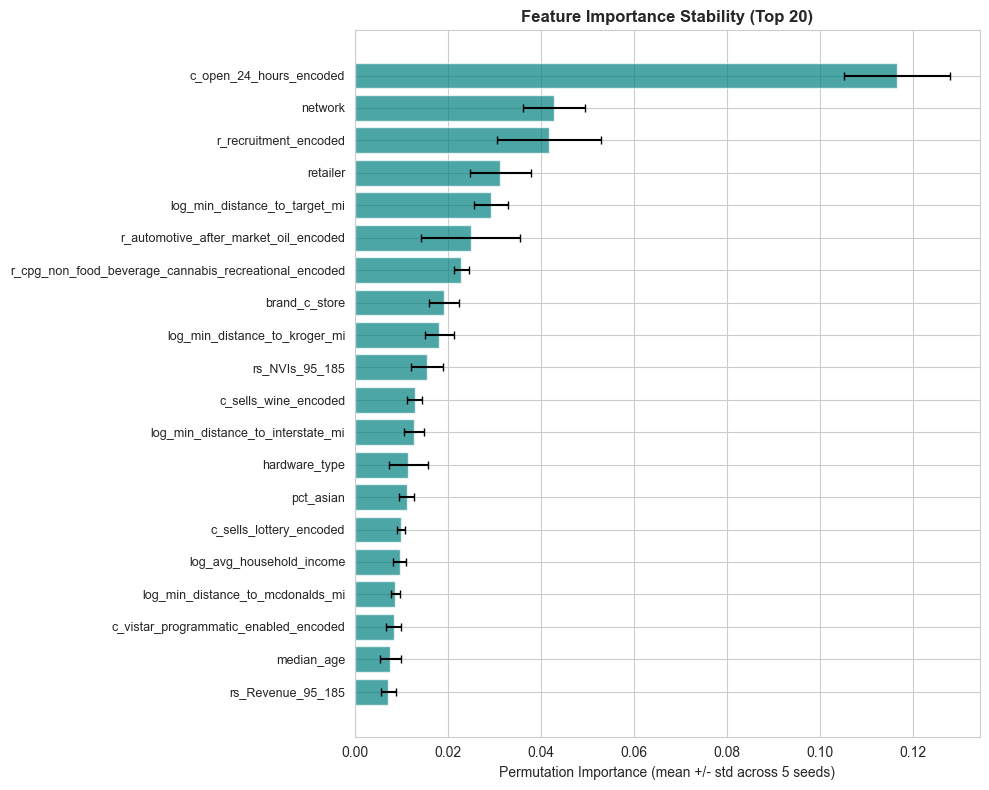


Most stable features (lowest coefficient of variation):
  schedule_site_encoded                         CV = 0.000  (mean imp = 0.0000)
  r_cpg_non_food_beverage_cannabis_recreational_encoded CV = 0.071  (mean imp = 0.0229)
  c_sells_lottery_encoded                       CV = 0.087  (mean imp = 0.0099)
  c_open_24_hours_encoded                       CV = 0.098  (mean imp = 0.1166)
  log_min_distance_to_mcdonalds_mi              CV = 0.111  (mean imp = 0.0087)
  r_retail_car_wash_encoded                     CV = 0.115  (mean imp = 0.0050)
  c_sells_wine_encoded                          CV = 0.126  (mean imp = 0.0129)
  log_min_distance_to_target_mi                 CV = 0.126  (mean imp = 0.0292)
  pct_asian                                     CV = 0.142  (mean imp = 0.0111)
  log_avg_household_income                      CV = 0.143  (mean imp = 0.0097)

-> Stable features are more trustworthy for production deployment.


In [23]:
# Feature importance stability across random seeds
print('Training 5 models with different random seeds and computing permutation importance...\n')

importance_runs = []
for seed in [42, 123, 456, 789, 1024]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        df[ALL_FEATURES].fillna(0).values, y_reg, test_size=0.2, random_state=seed
    )
    model = HistGradientBoostingRegressor(
        loss='squared_error', max_iter=300, learning_rate=0.03, max_depth=6,
        random_state=seed, verbose=0, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=30,
    )
    model.fit(X_tr, y_tr)

    # Permutation importance (5 repeats for speed)
    perm = permutation_importance(model, X_te, y_te, n_repeats=5,
                                  random_state=seed, n_jobs=-1)
    imp = pd.Series(perm.importances_mean, index=ALL_FEATURES)
    importance_runs.append(imp)
    print(f'  Seed {seed}: R2 = {r2_score(y_te, model.predict(X_te)):.4f}')

imp_df = pd.DataFrame(importance_runs)
imp_mean = imp_df.mean().sort_values(ascending=False)
imp_std = imp_df.std()

# Top 20 features by mean importance with stability bars
top20 = imp_mean.head(20)
top20_std = imp_std.reindex(top20.index)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top20))
ax.barh(y_pos, top20.values[::-1], xerr=top20_std.values[::-1],
        color='teal', alpha=0.7, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Permutation Importance (mean +/- std across 5 seeds)')
ax.set_title('Feature Importance Stability (Top 20)', fontweight='bold')
plt.tight_layout()
plt.show()

# Coefficient of variation (CV) -- low = stable
cv = (imp_std / imp_mean.clip(lower=1e-6)).sort_values()
print('\nMost stable features (lowest coefficient of variation):')
for feat in cv.head(10).index:
    print(f'  {feat:45s} CV = {cv[feat]:.3f}  (mean imp = {imp_mean[feat]:.4f})')
print('\n-> Stable features are more trustworthy for production deployment.')

---
## Section 9: Export Inference Results to CSV

Export per-site predictions for a selected model (task + feature subset).
Produces three files:
1. **Training sites** — site ID, actual revenue, percentile rank
2. **Test sites** — site ID, predictions, residuals, confidence metrics
3. **Metadata** — model type, features, metrics (JSON)

In [34]:
# ── Export Configuration ──────────────────────────────────────────────────────
# Set these two variables to select which experiment to export:

EXPORT_TASK   = 'classification'      # 'regression' or 'classification'
EXPORT_SUBSET = 'All Features'    # Must match a key in FEATURE_SUBSETS

# ── Validation ────────────────────────────────────────────────────────────────
import json as _json
from datetime import datetime
from scipy.stats import percentileofscore

assert EXPORT_TASK in ('regression', 'classification'), \
    f"EXPORT_TASK must be 'regression' or 'classification', got '{EXPORT_TASK}'"
assert EXPORT_SUBSET in FEATURE_SUBSETS, \
    f"EXPORT_SUBSET '{EXPORT_SUBSET}' not in FEATURE_SUBSETS. Valid keys: {list(FEATURE_SUBSETS.keys())}"

results_dict = reg_results if EXPORT_TASK == 'regression' else cls_results
assert EXPORT_SUBSET in results_dict, \
    f"No trained model found for '{EXPORT_SUBSET}' in {EXPORT_TASK} results."

EXPORT_DIR = PROJECT_ROOT / 'data' / 'processed' / 'exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Export task:   {EXPORT_TASK}')
print(f'Export subset: {EXPORT_SUBSET} ({len(FEATURE_SUBSETS[EXPORT_SUBSET])} features)')
print(f'Output dir:    {EXPORT_DIR}')
print(f'Train sites:   {len(idx_train):,}')
print(f'Test sites:    {len(idx_test):,}')

Export task:   classification
Export subset: All Features (52 features)
Output dir:    /Users/home/gkdev/geospatial/data/processed/exports
Train sites:   20,879
Test sites:    5,220


In [35]:
# ── Execute Export ─────────────────────────────────────────────────────────────
result = results_dict[EXPORT_SUBSET]
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
safe_subset = EXPORT_SUBSET.lower().replace(' ', '_')
prefix = f'{EXPORT_TASK}_{safe_subset}_{timestamp}'

# ── 1. Training sites CSV ─────────────────────────────────────────────────────
train_df = pd.DataFrame({
    'gtvid': df.iloc[idx_train]['gtvid'].values,
    'avg_monthly_revenue': y_reg[idx_train],
    'revenue_percentile': [
        percentileofscore(y_reg[idx_train], rev, kind='rank')
        for rev in y_reg[idx_train]
    ],
})
train_path = EXPORT_DIR / f'{prefix}_training_sites.csv'
train_df.to_csv(train_path, index=False)
print(f'Training sites: {train_path.name}  ({len(train_df):,} rows)')

# ── 2. Test sites CSV ─────────────────────────────────────────────────────────
test_gtvids = df.iloc[idx_test]['gtvid'].values
model = result['model']
X_te = result['X_test']

if EXPORT_TASK == 'regression':
    preds = model.predict(X_te)
    actuals = y_reg[idx_test]

    # Train quantile models for prediction intervals
    features = result['features']
    X_sub_full = df[features].fillna(0).values
    X_tr_q, X_te_q = X_sub_full[idx_train], X_sub_full[idx_test]
    y_tr_q = y_reg[idx_train]

    print('Training quantile models for prediction intervals...')
    q10_model = HistGradientBoostingRegressor(
        loss='quantile', quantile=0.1, max_iter=300, learning_rate=0.03,
        max_depth=6, random_state=42, verbose=0, early_stopping=False,
    )
    q90_model = HistGradientBoostingRegressor(
        loss='quantile', quantile=0.9, max_iter=300, learning_rate=0.03,
        max_depth=6, random_state=42, verbose=0, early_stopping=False,
    )
    q10_model.fit(X_tr_q, y_tr_q)
    q90_model.fit(X_tr_q, y_tr_q)
    q10_preds = q10_model.predict(X_te_q)
    q90_preds = q90_model.predict(X_te_q)

    test_df = pd.DataFrame({
        'gtvid': test_gtvids,
        'predicted_revenue': preds,
        'actual_revenue': actuals,
        'residual': np.abs(actuals - preds),
        'pred_interval_q10': q10_preds,
        'pred_interval_q90': q90_preds,
        'pred_interval_width': q90_preds - q10_preds,
    })

    metrics_dict = {
        'model_type': 'HistGradientBoostingRegressor',
        'test_r2': float(result['test_r2']),
        'test_rmse': float(result['test_rmse']),
        'test_mae': float(result['test_mae']),
    }

else:  # classification
    probs = model.predict_proba(X_te)[:, 1]
    actuals = y_cls[idx_test]
    test_auc = result['test_auc']

    test_df = pd.DataFrame({
        'gtvid': test_gtvids,
        'predicted_probability': probs,
        'actual_label': actuals,
        'residual': np.abs(actuals - probs),
        'model_roc_auc': test_auc,
    })

    metrics_dict = {
        'model_type': 'HistGradientBoostingClassifier',
        'test_auc': float(result['test_auc']),
        'test_f1': float(result['test_f1']),
        'test_precision': float(result['test_precision']),
        'test_recall': float(result['test_recall']),
        'lookalike_threshold_percentile': LOOKALIKE_PERCENTILE,
        'lookalike_threshold_revenue': float(threshold),
    }

test_path = EXPORT_DIR / f'{prefix}_test_predictions.csv'
test_df.to_csv(test_path, index=False)
print(f'Test predictions: {test_path.name}  ({len(test_df):,} rows)')

# ── 3. Metadata JSON ──────────────────────────────────────────────────────────
metadata = {
    'task': EXPORT_TASK,
    'feature_subset': EXPORT_SUBSET,
    'n_features': len(FEATURE_SUBSETS[EXPORT_SUBSET]),
    'features': FEATURE_SUBSETS[EXPORT_SUBSET],
    'n_train': len(idx_train),
    'n_test': len(idx_test),
    'random_state': 42,
    'test_size': 0.2,
    'exported_at': timestamp,
    'metrics': metrics_dict,
}
meta_path = EXPORT_DIR / f'{prefix}_metadata.json'
with open(meta_path, 'w') as f:
    _json.dump(metadata, f, indent=2)
print(f'Metadata:         {meta_path.name}')

print(f'\n── Export complete ──────────────────────────────────────────')
print(f'Files written to: {EXPORT_DIR}')
print(f'\nTraining sites preview:')
display(train_df.head())
print(f'\nTest predictions preview:')
display(test_df.head())

Training sites: classification_all_features_20260217_080733_training_sites.csv  (20,879 rows)
Test predictions: classification_all_features_20260217_080733_test_predictions.csv  (5,220 rows)
Metadata:         classification_all_features_20260217_080733_metadata.json

── Export complete ──────────────────────────────────────────
Files written to: /Users/home/gkdev/geospatial/data/processed/exports

Training sites preview:


,gtvid,avg_monthly_revenue,revenue_percentile
0,OTG010,14.190000,3.793285
1,TUG017,93.653617,28.310743
2,NYG274,369.642128,76.488338
3,BVG004,498.889574,85.051966
4,AUG058,147.183617,43.392883



Test predictions preview:


,gtvid,predicted_probability,actual_label,residual,model_roc_auc
0,CMG110,0.038771,0,0.038771,0.869959
1,EVG135,0.006308,0,0.006308,0.869959
2,BLG199,0.072029,0,0.072029,0.869959
3,ORG269,0.016090,1,0.983910,0.869959
4,BOG366,0.027450,0,0.027450,0.869959


---
## Section 10: Inference Export — Non-Active Sites

Run both regression and classification models on ~31K non-Active sites
(Temporarily Deactivated, Awaiting Installation, Deactivated, etc.)
and export per-site predictions with the same column structure as Section 9.

In [ ]:
# ── Load & preprocess non-Active sites ────────────────────────────────────────
from site_scoring.data_transform import get_all_sites_for_prediction

# User configuration: which feature subset to run inference with
INFERENCE_SUBSET = 'All Features'  # Must match a key in FEATURE_SUBSETS

# Validate subset exists in both regression and classification results
assert INFERENCE_SUBSET in FEATURE_SUBSETS, \
    f"'{INFERENCE_SUBSET}' not in FEATURE_SUBSETS. Valid: {list(FEATURE_SUBSETS.keys())}"
assert INFERENCE_SUBSET in reg_results, \
    f"No regression model for '{INFERENCE_SUBSET}'. Run Section 4 first."
assert INFERENCE_SUBSET in cls_results, \
    f"No classification model for '{INFERENCE_SUBSET}'. Run Section 5 first."

# Load all 57K sites with full derived features (same transforms as training)
all_sites_pl = get_all_sites_for_prediction()
non_active_pl = all_sites_pl.filter(pl.col('status') != 'Active')
print(f'\nNon-Active sites: {len(non_active_pl):,}')

# Status breakdown
status_counts = non_active_pl.group_by('status').agg(
    pl.len().alias('count')
).sort('count', descending=True)
print('\nStatus breakdown:')
for row in status_counts.iter_rows(named=True):
    print(f"  {row['status']:35s} {row['count']:>6,}")

# Convert to pandas for sklearn compatibility
infer_df = non_active_pl.to_pandas()

# Apply same label encoders from cell 4 (handle unseen categories safely)
# Use dict-based lookup instead of le.transform() to avoid KeyError on unseen labels
for col in CATEGORICAL_FEATURES:
    if col not in infer_df.columns:
        infer_df[col] = 0
        continue
    le = label_encoders[col]
    # Build class→int mapping; default to 0 for any unseen value
    class_to_int = {cls: i for i, cls in enumerate(le.classes_)}
    default_code = class_to_int.get('__MISSING__', 0)
    infer_df[col] = (
        infer_df[col]
        .fillna('__MISSING__')
        .astype(str)
        .map(lambda x, m=class_to_int, d=default_code: m.get(x, d))
    )
    n_unseen = (infer_df[col] == default_code).sum()
    if n_unseen > 0:
        print(f'  {col}: {n_unseen:,} unseen values mapped to default code {default_code}')

# Fill NaN in numeric/boolean features (same as cell 4)
for col in NUMERIC_FEATURES + BOOLEAN_FEATURES:
    if col in infer_df.columns:
        infer_df[col] = infer_df[col].fillna(0)

# Validate features exist in inference data
infer_features = FEATURE_SUBSETS[INFERENCE_SUBSET]
missing = [f for f in infer_features if f not in infer_df.columns]
if missing:
    print(f'\n⚠️  Missing features (zero-filled): {missing}')
    for f in missing:
        infer_df[f] = 0

X_infer = infer_df[infer_features].fillna(0).values
print(f'\nInference matrix: {X_infer.shape[0]:,} sites × {X_infer.shape[1]} features')
print(f'Feature subset:   {INFERENCE_SUBSET}')
print('Ready for inference.')

In [ ]:
# ── Run regression + classification inference & export ────────────────────────
import json as _json
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
safe_subset = INFERENCE_SUBSET.lower().replace(' ', '_')
EXPORT_DIR = PROJECT_ROOT / 'data' / 'processed' / 'exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── 1. Regression inference ──────────────────────────────────────────────────
reg_result = reg_results[INFERENCE_SUBSET]
reg_preds = reg_result['model'].predict(X_infer)

# Train quantile models on Active training data for prediction intervals
print('Training quantile models on Active training data for prediction intervals...')
X_train_q = df[infer_features].fillna(0).values[idx_train]
y_train_q = y_reg[idx_train]

q10_model = HistGradientBoostingRegressor(
    loss='quantile', quantile=0.1, max_iter=300, learning_rate=0.03,
    max_depth=6, random_state=42, verbose=0, early_stopping=False,
)
q90_model = HistGradientBoostingRegressor(
    loss='quantile', quantile=0.9, max_iter=300, learning_rate=0.03,
    max_depth=6, random_state=42, verbose=0, early_stopping=False,
)
q10_model.fit(X_train_q, y_train_q)
q90_model.fit(X_train_q, y_train_q)
q10_preds = q10_model.predict(X_infer)
q90_preds = q90_model.predict(X_infer)
print('  Quantile models trained.')

# Actual revenue for non-active sites (may be 0 for many)
actual_rev = infer_df['avg_monthly_revenue'].values if 'avg_monthly_revenue' in infer_df.columns \
    else np.zeros(len(infer_df))

reg_export_df = pd.DataFrame({
    'gtvid': infer_df['gtvid'].values,
    'status': infer_df['status'].values,
    'predicted_revenue': reg_preds,
    'actual_revenue': actual_rev,
    'residual': np.abs(actual_rev - reg_preds),
    'pred_interval_q10': q10_preds,
    'pred_interval_q90': q90_preds,
    'pred_interval_width': q90_preds - q10_preds,
})

reg_path = EXPORT_DIR / f'{safe_subset}_{timestamp}_non_active_regression.csv'
reg_export_df.to_csv(reg_path, index=False)
print(f'\nRegression CSV:     {reg_path.name}  ({len(reg_export_df):,} rows, {reg_export_df.shape[1]} cols)')

# ── 2. Classification inference ──────────────────────────────────────────────
cls_result = cls_results[INFERENCE_SUBSET]
cls_probs = cls_result['model'].predict_proba(X_infer)[:, 1]

# Binarize actual revenue using the same p90 threshold from training
actual_labels = (actual_rev >= threshold).astype(int)

cls_export_df = pd.DataFrame({
    'gtvid': infer_df['gtvid'].values,
    'status': infer_df['status'].values,
    'predicted_probability': cls_probs,
    'actual_label': actual_labels,
    'residual': np.abs(actual_labels - cls_probs),
    'model_roc_auc': cls_result['test_auc'],
})

cls_path = EXPORT_DIR / f'{safe_subset}_{timestamp}_non_active_classification.csv'
cls_export_df.to_csv(cls_path, index=False)
print(f'Classification CSV: {cls_path.name}  ({len(cls_export_df):,} rows, {cls_export_df.shape[1]} cols)')

# ── 3. Metadata JSON ─────────────────────────────────────────────────────────
status_breakdown = {
    row['status']: row['count']
    for row in status_counts.iter_rows(named=True)
}

metadata = {
    'task': 'non_active_inference',
    'feature_subset': INFERENCE_SUBSET,
    'n_features': len(infer_features),
    'features': infer_features,
    'n_sites': len(infer_df),
    'status_breakdown': status_breakdown,
    'regression_metrics': {
        'model_type': 'HistGradientBoostingRegressor',
        'test_r2': float(reg_result['test_r2']),
        'test_rmse': float(reg_result['test_rmse']),
        'test_mae': float(reg_result['test_mae']),
    },
    'classification_metrics': {
        'model_type': 'HistGradientBoostingClassifier',
        'test_auc': float(cls_result['test_auc']),
        'test_f1': float(cls_result['test_f1']),
        'test_precision': float(cls_result['test_precision']),
        'test_recall': float(cls_result['test_recall']),
    },
    'lookalike_threshold_percentile': LOOKALIKE_PERCENTILE,
    'lookalike_threshold_revenue': float(threshold),
    'exported_at': timestamp,
}

meta_path = EXPORT_DIR / f'{safe_subset}_{timestamp}_non_active_metadata.json'
with open(meta_path, 'w') as f:
    _json.dump(metadata, f, indent=2)
print(f'Metadata JSON:      {meta_path.name}')

print(f'\n── Non-Active Inference Export Complete ─────────────────────')
print(f'Output directory: {EXPORT_DIR}')

# Preview top predictions
print(f'\nRegression preview (top 10 by predicted revenue):')
display(reg_export_df.nlargest(10, 'predicted_revenue')[
    ['gtvid', 'status', 'predicted_revenue', 'actual_revenue', 'pred_interval_width']
])
print(f'\nClassification preview (top 10 by predicted probability):')
display(cls_export_df.nlargest(10, 'predicted_probability')[
    ['gtvid', 'status', 'predicted_probability', 'actual_label']
])